# Part 1 - Data Acquisition, Cleaning, and Exploratory Analysis

In [ ]:
# Task 1: Load the dataset

import pandas as pd
df = pd.read_csv(r"C:\Users\durga\Downloads\student_mental_health.csv")
print(df.head())
print(df.dtypes)
print(df.shape)

  Student_ID  Age  Gender  Year_of_Study  Sleep_Hours  Study_Hours_Per_Week  \
0    STU0001   22    Male              3          6.6                  17.6   
1    STU0002   21    Male              4          5.6                  22.4   
2    STU0003   22    Male              5          7.1                  28.1   
3    STU0004   24    Male              1          4.5                  14.8   
4    STU0005   20  Female              1          6.7                  17.2   

    GPA  Social_Media_Hours  Screen_Time_Hours Physical_Activity  \
0  2.91                 6.9                7.5          Moderate   
1  2.92                 7.6               11.5               Low   
2  2.68                 6.5                8.9               Low   
3  2.23                 5.5                7.6              High   
4  2.69                 4.3                7.0          Moderate   

   Financial_Stress  Family_Support  Attendance_Rate Part_Time_Job  \
0               8.5             4.0           

In [3]:
# Task 2: Null value Analysis

null_counts = df.isnull().sum()
null_percentage = (df.isnull().sum() / df.shape[0]) * 100
missing_data = pd.DataFrame({'Null_counts': null_counts, 'Null_percentage': null_percentage})
print(missing_data)

                                Null_counts  Null_percentage
Student_ID                                0             0.00
Age                                       0             0.00
Gender                                    0             0.00
Year_of_Study                             0             0.00
Sleep_Hours                              62             3.10
Study_Hours_Per_Week                      0             0.00
GPA                                      38             1.90
Social_Media_Hours                       58             2.90
Screen_Time_Hours                         0             0.00
Physical_Activity                         0             0.00
Financial_Stress                         91             4.55
Family_Support                           54             2.70
Attendance_Rate                          47             2.35
Part_Time_Job                             0             0.00
Diet_Quality                             69             3.45
Previous_Mental_Health_H

In [4]:
# columns with less than 20% null values

for col in df.columns:
    if null_percentage[col] < 20:
        if str(df[col].dtype) in ['int64', 'float64']:
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(df[col].mode()[0])

In [5]:

df.isnull().sum()


Student_ID                        0
Age                               0
Gender                            0
Year_of_Study                     0
Sleep_Hours                       0
Study_Hours_Per_Week              0
GPA                               0
Social_Media_Hours                0
Screen_Time_Hours                 0
Physical_Activity                 0
Financial_Stress                  0
Family_Support                    0
Attendance_Rate                   0
Part_Time_Job                     0
Diet_Quality                      0
Previous_Mental_Health_History    0
Mental_Health_Risk                0
dtype: int64

In [6]:
# Task 3: Duplicate row Analysis

dup_counts = df.duplicated().sum()
print("\n Number of duplicate rows : ", dup_counts)


 Number of duplicate rows :  0


In [7]:
# Task 4: Data type correction

# Report initial memory usage
memory_before = df.memory_usage(deep=True).sum()
print(f"Memory usage BEFORE conversion: {memory_before / 1024**2:.4f} MB")


# Convert repetitive string columns to 'category' data type
categorical_columns = ['Gender', 'Physical_Activity', 'Part_Time_Job', 'Diet_Quality', 'Previous_Mental_Health_History', 'Mental_Health_Risk']

for col in categorical_columns:
    df[col] = df[col].astype('category')

# Report final memory usage after conversion
memory_after = df.memory_usage(deep=True).sum()
print(f"\nMemory usage AFTER conversion: {memory_after / 1024**2:.4f} MB")

# Calculate total memory saved
memory_saved = memory_before - memory_after
print(f"\n Total Memory Saved: {memory_saved / 1024**2:.4f} MB")
print("\n Data types after conversion : ")
print(df.dtypes)

Memory usage BEFORE conversion: 0.3208 MB

Memory usage AFTER conversion: 0.1930 MB

 Total Memory Saved: 0.1278 MB

 Data types after conversion : 
Student_ID                             str
Age                                  int64
Gender                            category
Year_of_Study                        int64
Sleep_Hours                        float64
Study_Hours_Per_Week               float64
GPA                                float64
Social_Media_Hours                 float64
Screen_Time_Hours                  float64
Physical_Activity                 category
Financial_Stress                   float64
Family_Support                     float64
Attendance_Rate                    float64
Part_Time_Job                     category
Diet_Quality                      category
Previous_Mental_Health_History    category
Mental_Health_Risk                category
dtype: object


In [8]:
# Task 5: Descriptive statistics and skewness 

#  Descriptive statistics for all numeric columns
desc_stats = df.describe()
print("Descriptive Statistics:\n", desc_stats)

#  Compute skewness for each numeric column
numeric_cols = df.select_dtypes(include=['number']).columns
skewness_vals = df[numeric_cols].skew()
print("\nSkewness for each numeric column:\n", skewness_vals)

#  Identify and name the column with the highest absolute skewness
highest_skew_col = skewness_vals.abs().idxmax()
highest_skew_val = skewness_vals[highest_skew_col]
print(f"\nColumn with the highest absolute skewness: '{highest_skew_col}'")
print(f"Skewness Value: {highest_skew_val:.4f}")

Descriptive Statistics:
                Age  Year_of_Study  Sleep_Hours  Study_Hours_Per_Week  \
count  2000.000000    2000.000000  2000.000000           2000.000000   
mean     21.131500       2.630000     6.757050             19.997900   
std       2.139275       1.316802     1.109502              5.719274   
min      17.000000       1.000000     3.300000              2.400000   
25%      20.000000       1.000000     6.000000             16.000000   
50%      21.000000       2.000000     6.700000             19.800000   
75%      23.000000       4.000000     7.500000             24.000000   
max      29.000000       5.000000    10.000000             38.300000   

               GPA  Social_Media_Hours  Screen_Time_Hours  Financial_Stress  \
count  2000.000000         2000.000000        2000.000000       2000.000000   
mean      2.562455            6.013550           8.548500          5.962800   
std       0.340708            1.136568           1.657571          1.850572   
min       

In [9]:
# Task 6: Outlier Detection with IQR 
columns_for_outliers = ['Study_Hours_Per_Week', 'Screen_Time_Hours', 'GPA']

for col in columns_for_outliers:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"Number of outliers in '{col}': {outliers.shape[0]}")

Number of outliers in 'Study_Hours_Per_Week': 7
Number of outliers in 'Screen_Time_Hours': 7
Number of outliers in 'GPA': 9


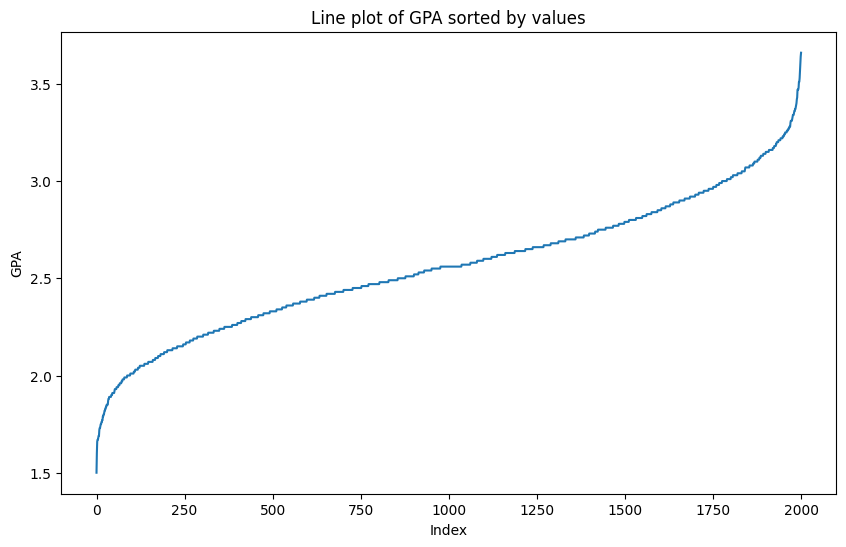

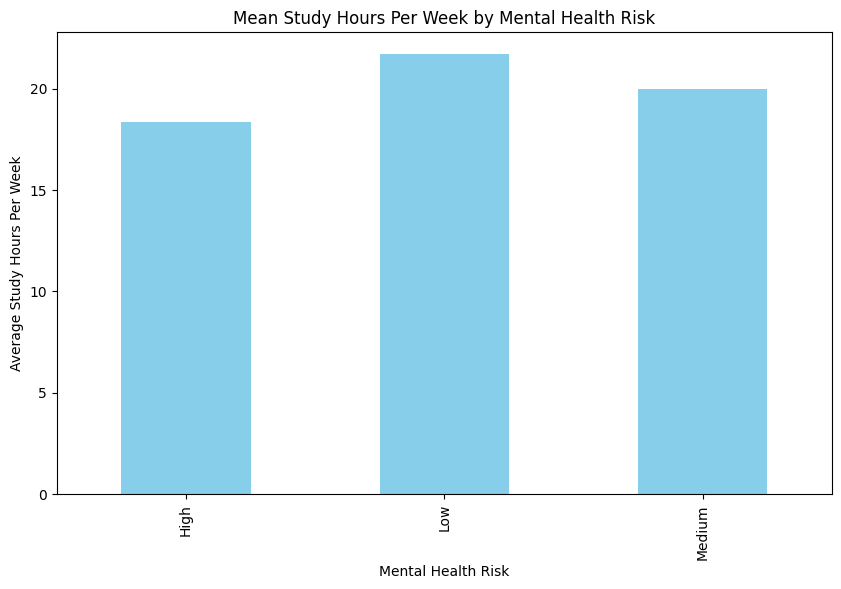

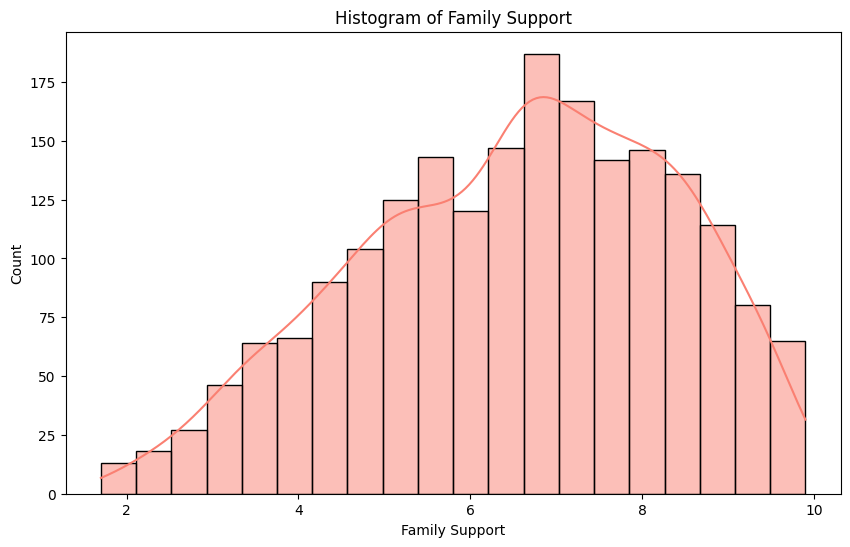

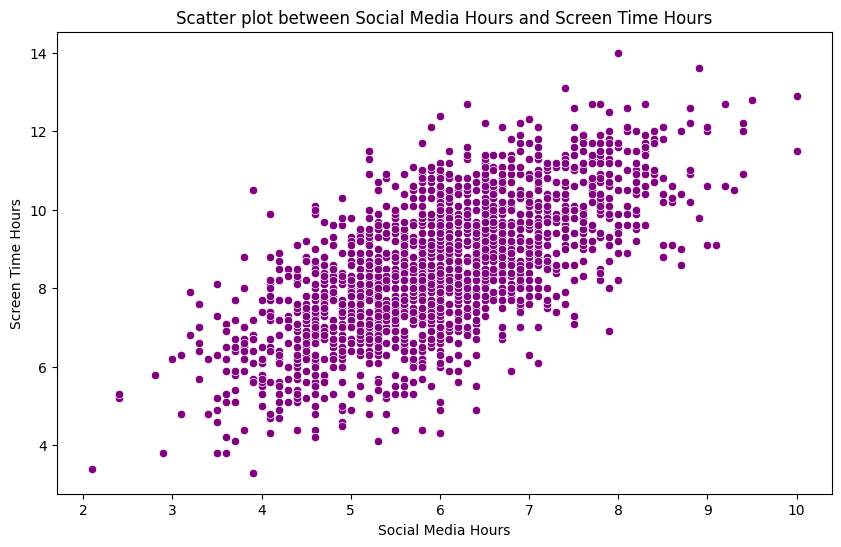

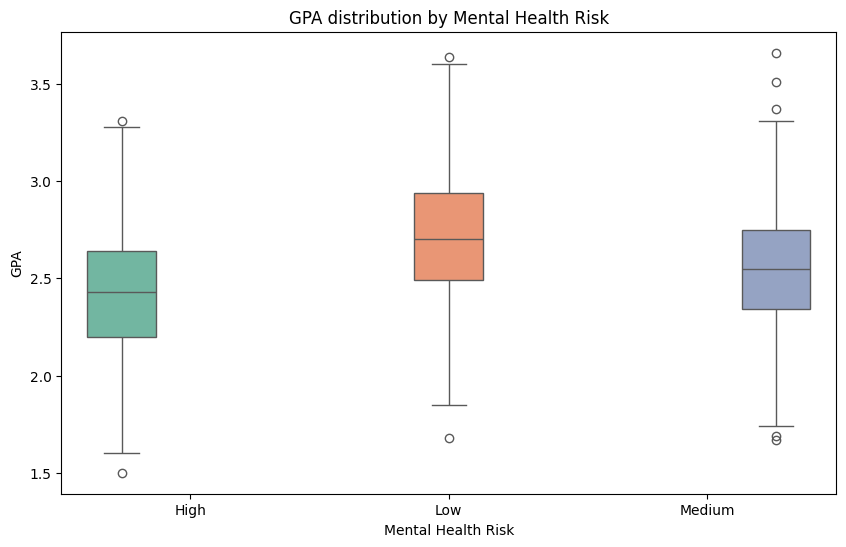

In [10]:
# Task 7: Visualization

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Line plot of a numeric variable 
plt.figure(figsize=(10, 6))
plt.plot(df["GPA"].sort_values().values)
plt.title("Line plot of GPA sorted by values")
plt.xlabel("Index")
plt.ylabel("GPA")
plt.savefig("line_plot.png")
plt.show()

# 2. Bar chart comparing mean of a numeric column across categories 
plt.figure(figsize=(10, 6))
df.groupby("Mental_Health_Risk")["Study_Hours_Per_Week"].mean().plot(kind="bar", color="skyblue")
plt.title("Mean Study Hours Per Week by Mental Health Risk")
plt.xlabel("Mental Health Risk")
plt.ylabel("Average Study Hours Per Week")
plt.savefig("bar_chart.png")
plt.show()

# 3. Histogram of the most skewed numeric column
plt.figure(figsize=(10, 6))
sns.histplot(df["Family_Support"], bins=20, kde=True, color="salmon")
plt.title("Histogram of Family Support")
plt.xlabel("Family Support")
plt.ylabel("Count")
plt.savefig("histogram.png")
plt.show()

# 4. Scatter plot between two correlated numeric columns 
plt.figure(figsize=(10, 6))
sns.scatterplot(x="Social_Media_Hours", y="Screen_Time_Hours", data=df, color="purple")
plt.title("Scatter plot between Social Media Hours and Screen Time Hours")
plt.xlabel("Social Media Hours")
plt.ylabel("Screen Time Hours")
plt.savefig("scatter_plot.png")
plt.show()

# 5. Box plot of a numeric column split by a categorical column 
plt.figure(figsize=(10, 6))
sns.boxplot(x="Mental_Health_Risk", y="GPA", data=df,hue="Mental_Health_Risk", palette="Set2", legend=False)
plt.title("GPA distribution by Mental Health Risk")
plt.xlabel("Mental Health Risk")
plt.ylabel("GPA")
plt.savefig("box_plot.png")
plt.show()

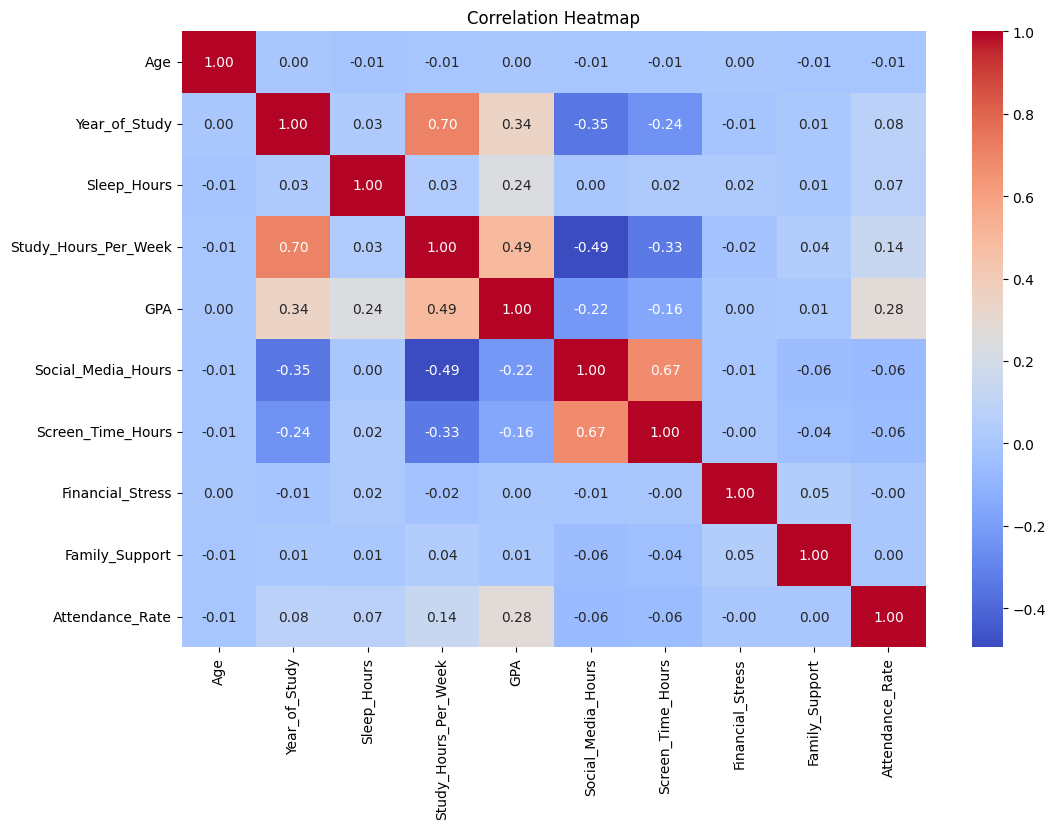

In [11]:
# Task 8: Correlation Heatmap

corr_matrix = df.select_dtypes(include=['float64', 'int64']).corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.savefig('correlation_heatmap.png')
plt.show()


In [12]:
# Task 9a : Imputation strategy comparison

# Identify the two numeric columns with highest absolute skewness
numeric_df = df.select_dtypes(include=['float64', 'int64']) 
skew_vals = numeric_df.skew().abs().sort_values(ascending=False)
top_2_skewed = skew_vals.head(2).index.tolist()

print(f"Top 2 Highly Skewed Columns: {top_2_skewed}\n")

# Compute and print mean and median side by side BEFORE imputation
for col in top_2_skewed:
    col_mean = df[col].mean()
    col_median = df[col].median()
    print(f"Column: {col} -> Mean: {col_mean:.4f} | Median: {col_median:.4f}")

# Apply the chosen strategy (Median) to fill remaining nulls
for col in top_2_skewed:
    df[col] = df[col].fillna(df[col].median())

# Confirm that no nulls remain using isnull().sum()
print("\nConfirmation (Nulls remaining):")
print(df[top_2_skewed].isnull().sum())



Top 2 Highly Skewed Columns: ['Family_Support', 'Year_of_Study']

Column: Family_Support -> Mean: 6.5232 | Median: 6.7000
Column: Year_of_Study -> Mean: 2.6300 | Median: 2.0000

Confirmation (Nulls remaining):
Family_Support    0
Year_of_Study     0
dtype: int64


In [13]:
# Task 9b : Spearman rank Correlation 

import numpy as np
import pandas as pd

# Create both correlation matrices
pearson_corr = numeric_df.corr(method="pearson")
spearman_corr = numeric_df.corr(method="spearman")

# Print the matrices
print("=== Pearson Correlation Matrix ===")
print(pearson_corr)
print("\n=== Spearman Rank Correlation Matrix ===")
print(spearman_corr)

# Calculate absolute difference: |Spearman - Pearson|
diff_corr = (spearman_corr - pearson_corr).abs()

# Find the top 3 largest differences
# To avoid duplicate pairs and self-correlation, we only take the upper triangle
mask = np.triu(np.ones_like(diff_corr, dtype=bool), k=1)
diff_pairs = diff_corr.where(mask).stack()

# Sort the values in descending order and get the top 3
top_3_pairs = diff_pairs.sort_values(ascending=False).head(3)

print("\n=== Top 3 Column Pairs with Largest Absolute Difference ===")
for indices, value in top_3_pairs.items():
    col1, col2 = indices
    s_val = abs(spearman_corr.loc[col1, col2])
    p_val = abs(pearson_corr.loc[col1, col2])
    print(f"Pair: ({col1}, {col2})")
    print(f" Difference: {value:.4f} | |Spearman|: {s_val:.4f} | |Pearson|: {p_val:.4f}")
    print("-" * 50)

=== Pearson Correlation Matrix ===
                           Age  Year_of_Study  Sleep_Hours  \
Age                   1.000000       0.002186    -0.010581   
Year_of_Study         0.002186       1.000000     0.025275   
Sleep_Hours          -0.010581       0.025275     1.000000   
Study_Hours_Per_Week -0.007476       0.703401     0.032017   
GPA                   0.001437       0.340848     0.239572   
Social_Media_Hours   -0.007482      -0.348413     0.002021   
Screen_Time_Hours    -0.005439      -0.239093     0.019187   
Financial_Stress      0.003662      -0.012754     0.023366   
Family_Support       -0.010051       0.008727     0.010547   
Attendance_Rate      -0.009510       0.077692     0.074933   

                      Study_Hours_Per_Week       GPA  Social_Media_Hours  \
Age                              -0.007476  0.001437           -0.007482   
Year_of_Study                     0.703401  0.340848           -0.348413   
Sleep_Hours                       0.032017  0.239572  

In [14]:
# Task 9c : Grouped Aggregation 

# Select the categorical column and numeric column
categorical_col = "Mental_Health_Risk"
numeric_col = "Sleep_Hours"

# 1. Groupby aggregation
grouped_stats = df.groupby(categorical_col)[numeric_col].agg(
    ["mean", "std", "count"]
)
print(f"=== Grouped Aggregation: {numeric_col} by {categorical_col} ===\n")
print(grouped_stats)

# 2. Find the group with the highest mean and highest std
highest_mean_group = grouped_stats["mean"].idxmax()
highest_std_group = grouped_stats["std"].idxmax()

print("\n--- README Requirements ---")
print(
    f"(a) Group with Highest Mean: {highest_mean_group} (Value: {grouped_stats.loc[highest_mean_group, 'mean']:.4f})"
)
print(
    f"(a) Group with Highest Std: {highest_std_group} (Value: {grouped_stats.loc[highest_std_group, 'std']:.4f})"
)

# 3. Compute the ratio of the highest mean to the lowest mean
highest_mean = grouped_stats["mean"].max()
lowest_mean = grouped_stats["mean"].min()

# Ratio calculation
if lowest_mean != 0:
    mean_ratio = highest_mean / lowest_mean
else:
    mean_ratio = float("inf")

print(f"(c) Ratio of Highest to Lowest Group Mean: {mean_ratio:.4f}")

=== Grouped Aggregation: Sleep_Hours by Mental_Health_Risk ===

                        mean       std  count
Mental_Health_Risk                           
High                6.056765  0.940066    680
Low                 7.507424  0.966506    660
Medium              6.728182  0.904781    660

--- README Requirements ---
(a) Group with Highest Mean: Low (Value: 7.5074)
(a) Group with Highest Std: Low (Value: 0.9665)
(c) Ratio of Highest to Lowest Group Mean: 1.2395


In [15]:
# Task 10 : save the clean dataset

df.to_csv('cleaned_data.csv', index=False)
print("\nCleaned dataset has been successfully saved as 'cleaned_data.csv'")


Cleaned dataset has been successfully saved as 'cleaned_data.csv'
